I used Gemini with the guided learning enabled to help me with understanding, and walking me through the steps to solve everything while asking questions of me and I of it.


# EX5.1

In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

In [3]:
car_mileages = pd.read_csv("passengercarmileage.txt", sep='\t')

car_mileages

,makeAndModel,VOL,HP,MPG,SP,WT
0,GM/GeoMetroXF1,89,49,65.4,96,17.5
1,GM/GeoMetro,92,55,56.0,97,20.0
2,GM/GeoMetroLSI,92,55,55.9,97,20.0
3,SuzukiSwift,92,70,49.0,105,20.0
4,DaihatsuCharade,92,53,46.5,96,20.0
...,...,...,...,...,...,...
77,Mercedes500SL,50,322,18.1,165,45.0
78,Mercedes560SEL,115,238,17.2,140,45.0
79,JaguarXJSConvert,50,263,17.0,147,45.0
80,BMW750IL,119,295,16.7,157,45.0


In [4]:
X = car_mileages["HP"].values
Y = car_mileages["MPG"].values

with pm.Model() as model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * X
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y)
    
    trace = pm.sample(draws=1000, tune=1000, return_inferencedata=True)

# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace, var_names=["alpha", "beta", "sigma"]))

NUTS[nutpie]: [alpha, beta, sigma]


Output()

          mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha     50.1    1.58       48       53     1056     1272  1.00     0.049    0.033
beta   -0.1393  0.0121    -0.16    -0.12     1081     1355  1.00   0.00037  0.00025
sigma     6.26    0.49      5.5      7.1     2038     2023  1.00     0.011   0.0081


Sampling: [y_obs]


Output()

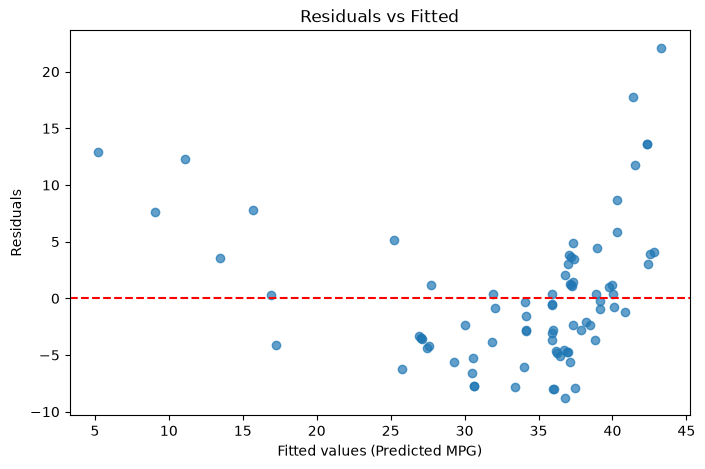

In [5]:
#non-log
with model:
    ppc = pm.sample_posterior_predictive(trace)

#mean predicted values
y_pred = ppc.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
residuals = Y - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (Predicted MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#the shape is curved (kind of U-shaped), there isn't a clear linear relationship here.

In [6]:
Y_log = np.log(car_mileages["MPG"].values)

with pm.Model() as log_model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * X
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y_log)
    
    trace_log = pm.sample(draws=1000, tune=1000, return_inferencedata=True)

# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace_log, var_names=["alpha", "beta", "sigma"]))

NUTS[nutpie]: [alpha, beta, sigma]


Output()

           mean       sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
alpha     4.012    0.041      3.9      4.1     1169     1413  1.00    0.0012  0.00086
beta   -0.00458  0.00032  -0.0051  -0.0041     1159     1503  1.00   9.3e-06  7.1e-06
sigma    0.1604   0.0134     0.14     0.18     2169     1848  1.00   0.00029  0.00025


Sampling: [y_obs]


Output()

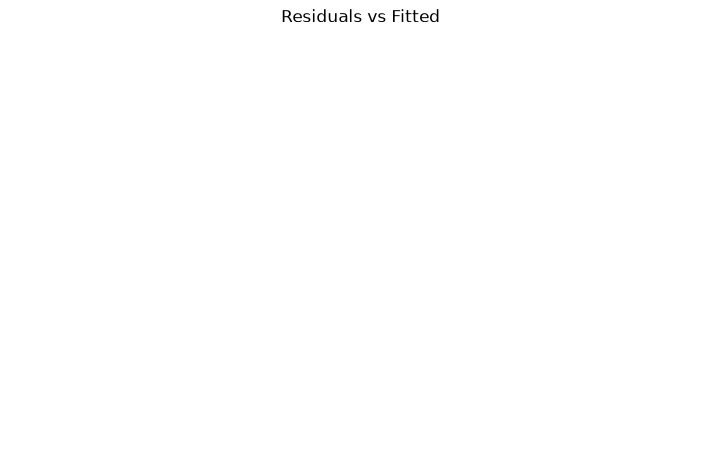

In [7]:
#logged
with model:
    ppc = pm.sample_posterior_predictive(trace_log)

#mean predicted values
y_pred = ppc.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
residuals = Y_log - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (Predicted MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

#the shape is better, so improved linear relationship, but not perfect

In [17]:
X_multi = car_mileages[["VOL", "HP", "SP", "WT"]].values
Y_multi = car_mileages["MPG"].values

#normalize
X_mean = X_multi.mean(axis=0)
X_std = X_multi.std(axis=0)
X_scaled = (X_multi - X_mean) / X_std


with pm.Model() as multi_model:
    #weakly informative values
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    #coefficient vector
    betas = pm.Normal("betas", mu=0, sigma=10, shape=4)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + pm.math.dot(X_scaled, betas)
    
    likelihood = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=Y_multi)
    
    trace_multi = pm.sample(draws=1000, tune=1000, return_inferencedata=True)
    trace_multi = pm.sample_posterior_predictive(
            trace_multi, 
            extend_inferencedata=True
        )
# Print summary of the parameters (means correspond to regression coefficients)
print(pm.stats.summary(trace_multi, var_names=["alpha", "betas", "sigma"]))

NUTS[nutpie]: [alpha, betas, sigma]


Output()

Sampling: [y_obs]


Output()

           mean    sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
alpha     33.78  0.41       33       34     3569     2474  1.00    0.0068  0.0071
betas[0]  -0.52  0.51     -1.3      0.3     3108     2745  1.00    0.0092  0.0087
betas[1]   15.7   3.9      9.3       22      482      762  1.00      0.18    0.12
betas[2]  -13.3   2.9      -18     -8.6      501      821  1.00      0.13   0.083
betas[3]  -12.8  1.52      -15      -10      556      899  1.00     0.065   0.039
sigma      3.74  0.31      3.3      4.3     3107     2614  1.00    0.0055  0.0053


In [18]:
# import arviz_stats as az
# r2_summary = az.bayesian_r2(Y_multi, trace_multi)
# print(r2_summary)

# y_pred_multi = trace_multi.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
y_pred_multi = trace_multi.posterior_predictive["y_obs"].mean(dim=["chain", "draw"]).values
ss_res = np.sum((Y_multi - y_pred_multi) ** 2)
ss_tot = np.sum((Y_multi - np.mean(Y_multi)) ** 2)
r2_multi = 1 - (ss_res / ss_tot)

print("Multiple Model R²:", r2_multi)


Multiple Model R²: 0.8687574672023537


### Personal notes
-  outcome $y$ as a Normal distribution centered on our line:$$\text{MPG}_i \sim \text{Normal}(\mu_i, \sigma)$$$$\mu_i = \alpha + \beta \cdot \text{HP}_i$$
-  Posterior Predictive Checks (PPC) to compute the predicted values ($\hat{y}$) and calculate the residuals
-  Heteroscedasticity means that the variance of errors or residuals in a statistical model is not constant across the values of an independent variable

# Ex5.2

1. Least Squares Estimate

residuals:
$$e_i = Y_i - \beta X_i$$

$$RSS = \sum_{i=1}^n (Y_i - \beta X_i)^2$$


Chain rule:

$u = Y_i - \beta X_i$


$\frac{d}{du} = 2u$
$\frac{d}{d\beta} = -X_1$

$\frac{d}{du} * \frac{d}{\beta} = -2X_1u
=-2X_1(Y_i - \beta X_i)$

$$\frac{dRSS}{d\beta} = \sum_{i=1}^n -2 X_i (Y_i - \beta X_i)$$


$$ -2\sum_{i=1}^n (X_iY_i - \beta X_i^2)$$

$$\sum_{i=1}^n X_i Y_i - \sum_{i=1}^n \beta X_i^2 = 0$$

$$\sum_{i=1}^n X_i Y_i - \beta \sum_{i=1}^n X_i^2$$

Estimator: $\hat\beta$
$$\hat\beta = \frac{-\sum_{i=1}^n X_i Y_i}{-\sum_{i=1}^n X_i^2}$$
$$ = \frac{\sum_{i=1}^n X_i Y_i}{\sum_{i=1}^n X_i^2}$$


### personal notes
- $Y_i = \beta X_i + \epsilon_i$ -- forced to pass through the origin since $\beta_0$ isn't present